# Emotion Detection in Text Messages

This project is about building a machine learning model that can detect emotions in text. The model will analyze messages and classify them into emotions such as joy, sadness, anger, fear, love, and surprise.

![Project Image](img.jpg)

In [157]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC


## --- Data Design ---

### Load Dataset

We load the raw CSV file here.
The original file is not edited on disk; all changes happen in code inside this notebook.


In [158]:
df = pd.read_csv("combined_emotion.csv")

# Basic column cleanup and label normalization.
df["sentence"] = df["sentence"].astype(str).str.strip()
df["emotion"] = (
    df["emotion"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"suprise": "surprise"})
)

# Remove rows missing required values.
df = df[(df["sentence"] != "") & (df["emotion"] != "")].reset_index(drop=True)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_sentence"] = df["sentence"].apply(clean_text)

df.head()


,sentence,emotion,clean_sentence
0,i just feel really helpless and heavy hearted,fear,i just feel really helpless and heavy hearted
1,ive enjoyed being able to slouch about relax a...,sad,ive enjoyed being able to slouch about relax a...
2,i gave up my internship with the dmrg and am f...,fear,i gave up my internship with the dmrg and am f...
3,i dont know i feel so lost,sad,i dont know i feel so lost
4,i am a kindergarten teacher and i am thoroughl...,fear,i am a kindergarten teacher and i am thoroughl...


### Deduplicate and Balance Labels

First we remove duplicate sentences.
Then we randomly downsample each emotion so every label has the same number of rows.
We use `random_state=42` so you can reproduce the same sample again.


In [159]:
rows_before = len(df)
df = df.drop_duplicates(subset=["clean_sentence"]).reset_index(drop=True)
rows_after = len(df)

print(f"Removed {rows_before - rows_after} duplicate sentences.")
print(f"Rows after deduplication: {rows_after}")

# Downsample each class to the smallest class size.
target_size = df["emotion"].value_counts().min()

df = (
    df.groupby("emotion", group_keys=False)
      .sample(n=target_size, random_state=42)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print(f"Balanced rows per label: {target_size}")
print(df["emotion"].value_counts())


Removed 28924 duplicate sentences.
Rows after deduplication: 393822
Balanced rows per label: 12407
emotion
anger       12407
joy         12407
sad         12407
surprise    12407
fear        12407
love        12407
Name: count, dtype: int64


### Dataset Overview

The raw dataset starts with over 422,000 text samples labeled with emotions.

After preprocessing in this notebook, labels are cleaned and standardized (including `suprise` -> `surprise`), duplicate sentences are removed, and each emotion is downsampled to create an equal class distribution.

The working dataframe uses two columns:
- sentence: the input text
- emotion: the label


In [160]:
df.info()
df["emotion"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 74442 entries, 0 to 74441
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   sentence        74442 non-null  str  
 1   emotion         74442 non-null  str  
 2   clean_sentence  74442 non-null  str  
dtypes: str(3)
memory usage: 1.7 MB


emotion
anger       12407
joy         12407
sad         12407
surprise    12407
fear        12407
love        12407
Name: count, dtype: int64

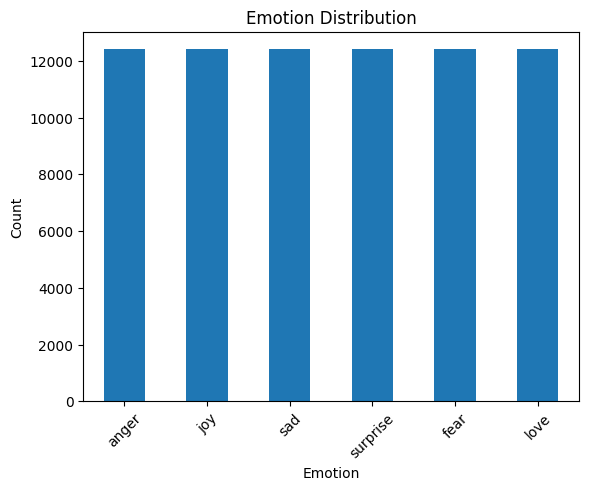

In [161]:
import matplotlib.pyplot as plt

df["emotion"].value_counts().plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

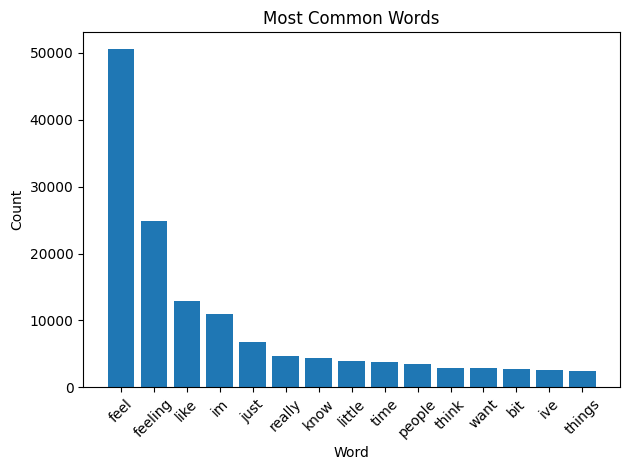

In [162]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

cv = CountVectorizer(stop_words="english", max_features=15)
word_counts = cv.fit_transform(df["clean_sentence"].fillna(""))
word_sums = word_counts.sum(axis=0).A1

words_df = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "count": word_sums
}).sort_values("count", ascending=False)

plt.bar(words_df["word"], words_df["count"])
plt.title("Most Common Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Data Cleaning

We clean each sentence by lowercasing text, removing punctuation/noise, and fixing extra spaces.
This makes the text more consistent for feature extraction.


In [163]:
# Preview original vs cleaned text.
df[["sentence", "clean_sentence"]].head()

,sentence,clean_sentence
0,i feel like being bitchy and cursing him or so...,i feel like being bitchy and cursing him or so...
1,im happy to be back blogging however and feeli...,im happy to be back blogging however and feeli...
2,im knitting a size up since i havent lost the ...,im knitting a size up since i havent lost the ...
3,i love thinking up recipes starting with one i...,i love thinking up recipes starting with one i...
4,ive taken the lortab twice today and think the...,ive taken the lortab twice today and think the...


### Train, Validation, and Test Split
The dataset is split into training, validation, and test sets.

The training set is used to train the model.  
The validation set is used to evaluate and improve the model during development.  
The test set is used for final evaluation.

Stratified splitting is used to maintain the same distribution of emotion labels across all sets.

In [164]:
X = df["clean_sentence"]
y = df["emotion"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.40, random_state=42, stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 37221
Validation samples: 22332
Test samples: 14889


### Feature Extraction (TF-IDF)

TF-IDF converts text into numbers for the model.
We remove very common words using English stop words, extra custom stop words (`feel`, `feeling`, `like`, `im`), and `max_df=0.85`.


In [165]:
custom_stop_words = ["feel", "feeling", "like", "im"]
all_stop_words = list(ENGLISH_STOP_WORDS.union(custom_stop_words))

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=all_stop_words,
    max_df=0.85,
    min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_vec.shape)


TF-IDF shape: (37221, 5000)


## --- Modelling & Evaluation ---

The dataset is balanced before training, so both models learn from equal label sizes.


### KNN Model (Baseline)

This is a simple baseline using nearest neighbors on the TF-IDF vectors.


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=29, metric="cosine")

knn_model.fit(X_train_vec, y_train)
print("KNN trained with k=29")


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### KNN Validation Evaluation


In [167]:
y_val_pred_knn = knn_model.predict(X_val_vec)

print(classification_report(y_val, y_val_pred_knn))


              precision    recall  f1-score   support

       anger       0.89      0.88      0.89      3722
        fear       0.87      0.87      0.87      3722
         joy       0.86      0.83      0.85      3722
        love       0.88      0.89      0.89      3722
         sad       0.89      0.86      0.88      3722
    surprise       0.84      0.88      0.86      3722

    accuracy                           0.87     22332
   macro avg       0.87      0.87      0.87     22332
weighted avg       0.87      0.87      0.87     22332



#### KNN Test Evaluation


In [168]:
y_test_pred_knn = knn_model.predict(X_test_vec)

print(classification_report(y_test, y_test_pred_knn))


              precision    recall  f1-score   support

       anger       0.89      0.88      0.88      2481
        fear       0.86      0.88      0.87      2481
         joy       0.86      0.82      0.84      2482
        love       0.87      0.88      0.88      2482
         sad       0.89      0.87      0.88      2482
    surprise       0.83      0.86      0.85      2481

    accuracy                           0.87     14889
   macro avg       0.87      0.87      0.87     14889
weighted avg       0.87      0.87      0.87     14889



#### KNN Confusion Matrix

This shows which emotion classes the KNN model mixes up.


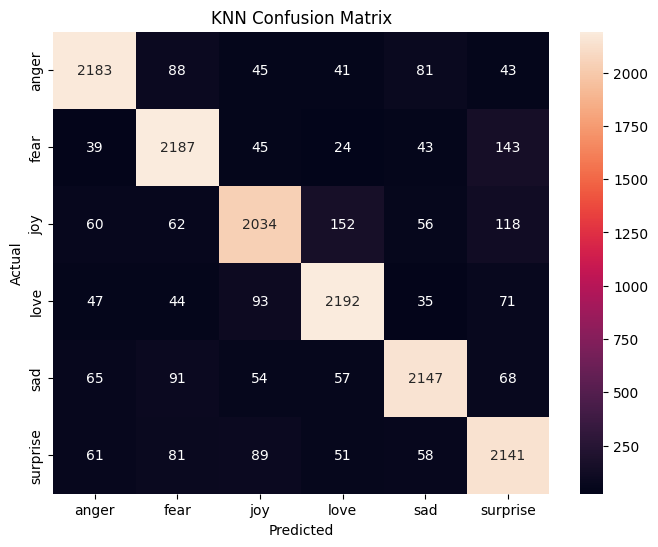

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(knn_model.classes_)
cm_knn = confusion_matrix(y_test, y_test_pred_knn, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()


#### KNN Performance per Emotion


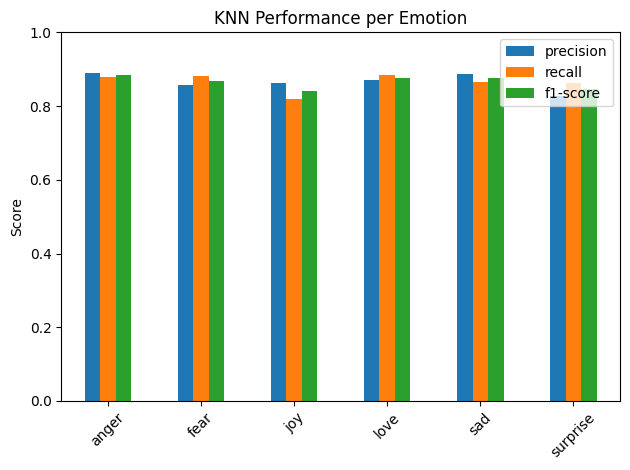

In [170]:
report_knn = classification_report(y_test, y_test_pred_knn, output_dict=True)
report_knn_df = pd.DataFrame(report_knn).transpose()

report_knn_df.iloc[:-3][["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("KNN Performance per Emotion")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Logistic Regression Model

This is the stronger linear baseline for sparse text features like TF-IDF.


In [171]:
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train_vec, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Logistic Regression Validation Evaluation


In [172]:
y_val_pred_lr = lr_model.predict(X_val_vec)

print(classification_report(y_val, y_val_pred_lr))


              precision    recall  f1-score   support

       anger       0.94      0.92      0.93      3722
        fear       0.92      0.89      0.91      3722
         joy       0.90      0.90      0.90      3722
        love       0.94      0.96      0.95      3722
         sad       0.94      0.91      0.92      3722
    surprise       0.92      0.97      0.94      3722

    accuracy                           0.93     22332
   macro avg       0.93      0.93      0.93     22332
weighted avg       0.93      0.93      0.93     22332



#### Logistic Regression Test Evaluation


In [173]:
y_test_pred_lr = lr_model.predict(X_test_vec)

print(classification_report(y_test, y_test_pred_lr))


              precision    recall  f1-score   support

       anger       0.95      0.91      0.93      2481
        fear       0.92      0.90      0.91      2481
         joy       0.91      0.90      0.90      2482
        love       0.94      0.97      0.95      2482
         sad       0.93      0.92      0.92      2482
    surprise       0.92      0.97      0.94      2481

    accuracy                           0.93     14889
   macro avg       0.93      0.93      0.93     14889
weighted avg       0.93      0.93      0.93     14889



#### Logistic Regression Confusion Matrix

This shows which emotion classes the logistic model mixes up.


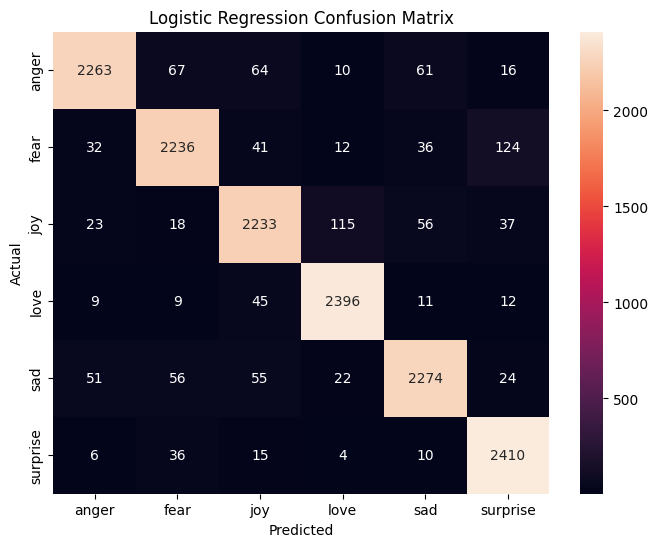

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(lr_model.classes_)
cm_lr = confusion_matrix(y_test, y_test_pred_lr, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


#### Logistic Regression Performance per Emotion


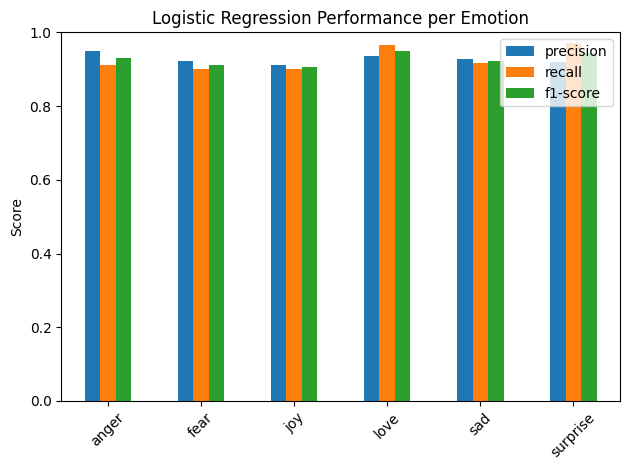

In [175]:
report_lr = classification_report(y_test, y_test_pred_lr, output_dict=True)
report_lr_df = pd.DataFrame(report_lr).transpose()

report_lr_df.iloc[:-3][["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("Logistic Regression Performance per Emotion")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### SVM Model

This section uses a linear Support Vector Machine, which is a strong text-classification baseline for TF-IDF features.


In [ ]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_vec, y_train)


#### SVM Validation Evaluation


In [ ]:
y_val_pred_svm = svm_model.predict(X_val_vec)

print(classification_report(y_val, y_val_pred_svm))


#### SVM Test Evaluation


In [ ]:
y_test_pred_svm = svm_model.predict(X_test_vec)

print(classification_report(y_test, y_test_pred_svm))


#### SVM Confusion Matrix

This shows which emotion classes the SVM model mixes up.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(svm_model.classes_)
cm_svm = confusion_matrix(y_test, y_test_pred_svm, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()


#### SVM Performance per Emotion


In [ ]:
report_svm = classification_report(y_test, y_test_pred_svm, output_dict=True)
report_svm_df = pd.DataFrame(report_svm).transpose()

report_svm_df.iloc[:-3][["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("SVM Performance per Emotion")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Model Comparison

This graph compares all three models on the same test set.
Higher values mean better performance.


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

model_predictions = {
    "KNN": y_test_pred_knn,
    "Logistic Regression": y_test_pred_lr,
    "SVM": y_test_pred_svm,
}

comparison_rows = []

for model_name, y_pred in model_predictions.items():
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    comparison_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": p_macro,
        "Macro Recall": r_macro,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)
display(comparison_df.round(4))

plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
ax.set_title("Model Performance Comparison (Test Set)")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

plt.tight_layout()
plt.show()


### Custom Text Check (Logistic Regression)

This section tests the trained logistic model on your own text.


In [176]:
custom_text = "Wow what the hell"

cleaned = clean_text(custom_text)
text_vec = vectorizer.transform([cleaned])

probs = lr_model.predict_proba(text_vec)[0]
classes = lr_model.classes_
ranked = sorted(zip(classes, probs), key=lambda x: x[1], reverse=True)

print("Text:", custom_text)
print("\nEmotion probability spread:")
for emotion, p in ranked:
    print(f"{emotion:10s} {p * 100:.2f}%")

print("\nPredicted emotion:", ranked[0][0])


Text: Wow what the hell

Emotion probability spread:
sad        31.10%
joy        24.44%
fear       15.01%
anger      12.15%
love       11.33%
surprise   5.98%

Predicted emotion: sad
